Usando o exemplo 499

In [1]:
%pip install pandas numpy seaborn tensorflow
%pip install nltk
%pip install lime
%pip install imbalanced-learn
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
import shap


from lime import lime_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.feature_extraction.text import TfidfVectorizer

c:\Users\LUIRYS SILVA\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv('../FakeNewsNet.csv')

In [4]:
df.head()

,title,news_url,source_domain,tweet_num,real
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,42,1
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0,1
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,63,1
3,Colombian singer Maluma sparks rumours of inap...,https://www.dailymail.co.uk/news/article-33655...,www.dailymail.co.uk,20,1
4,Gossip Girl 10 Years Later: How Upper East Sid...,https://www.zerchoo.com/entertainment/gossip-g...,www.zerchoo.com,38,1


In [5]:
df.shape

(23196, 5)

<Axes: xlabel='real', ylabel='count'>

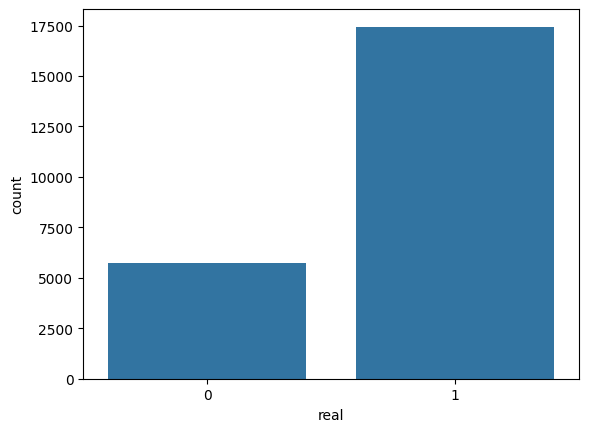

In [6]:
sns.countplot(x='real', data=df)

**Pré-Processamento**

In [7]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re

# Baixar pacotes necessários do NLTK
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")
nltk.download('punkt_tab') # Download the 'punkt_tab' resource

[nltk_data] Downloading package stopwords to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [8]:
def preprocess_text(text):
    # Converter para minúsculas
    text = text.lower()

    # Remover caracteres especiais e números
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Tokenização (dividir em palavras)
    tokens = word_tokenize(text)

    # Remover stopwords
    stop_words = set(stopwords.words("english"))
    tokens = [word for word in tokens if word not in stop_words]

    # Lematização (reduzir palavras à sua forma base)
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Juntar as palavras processadas de volta em uma string
    return " ".join(tokens)

In [9]:
df["clean_text"] = df["title"].apply(preprocess_text)

In [10]:
df.head(5)

,title,news_url,source_domain,tweet_num,real,clean_text
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,42,1,kandi burruss explodes rape accusation real ho...
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0,1,people choice award best red carpet look
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,63,1,sophia bush sends sweet birthday message one t...
3,Colombian singer Maluma sparks rumours of inap...,https://www.dailymail.co.uk/news/article-33655...,www.dailymail.co.uk,20,1,colombian singer maluma spark rumour inappropr...
4,Gossip Girl 10 Years Later: How Upper East Sid...,https://www.zerchoo.com/entertainment/gossip-g...,www.zerchoo.com,38,1,gossip girl year later upper east siders shock...


<Axes: xlabel='real', ylabel='count'>

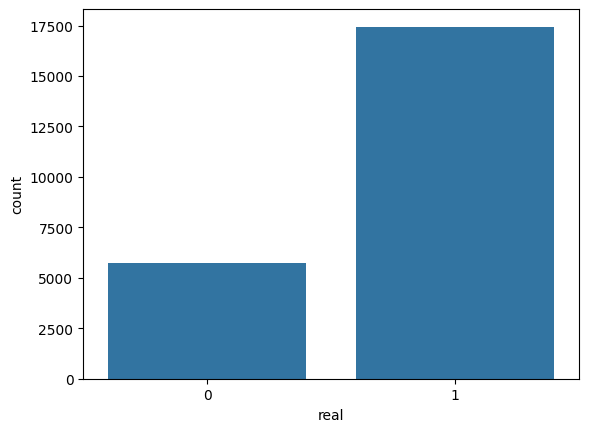

In [11]:
sns.countplot(x="real", data=df) # validando se mudou as classes

In [12]:
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['real'])

In [13]:
X = df['clean_text']
y = df['label_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#, stratify=y

In [14]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words=None
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

**OVERSAMPLING**

In [15]:
from imblearn.over_sampling import RandomOverSampler

# Separar a validação ANTES do oversampling (evita duplicatas na validação)
X_tr_orig, X_val, y_tr_orig, y_val = train_test_split(
    X_train_tfidf, y_train,
    test_size=0.1,
    stratify=y_train,
    random_state=42
)

ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_tr_orig, y_tr_orig)

<Axes: xlabel='label_encoded', ylabel='count'>

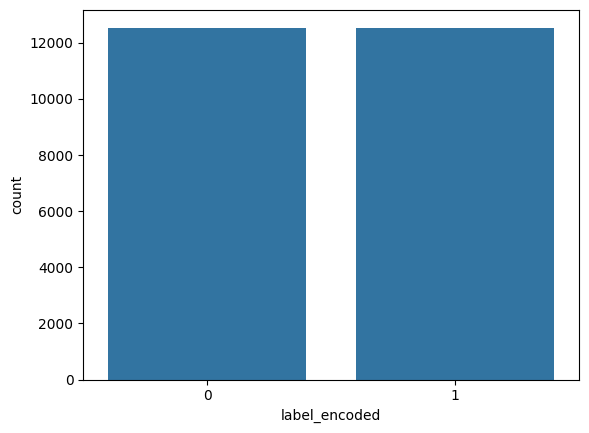

In [16]:
#verificar a nova distribuição de classes
sns.countplot(x=y_train_resampled)

**MLP**

In [17]:
model = Sequential()

model.add(Dense(
    256,
    activation='relu',
    input_shape=(X_train_tfidf.shape[1],)
))

model.add(Dropout(0.5))

model.add(Dense(
    128,
    activation='relu'
))

model.add(Dropout(0.3))

model.add(Dense(
    3,
    activation='softmax'
))

c:\Users\LUIRYS SILVA\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
# Compilar o modelo
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',  # Use sparse_categorical_crossentropy se y_train for numérico
              metrics=['accuracy'])

In [19]:
history = model.fit(X_train_resampled,
                    y_train_resampled,
                    epochs=10,
                    batch_size=32,
                    validation_data=(X_val.toarray(), y_val))

Epoch 1/10
784/784 ━━━━━━━━━━━━━━━━━━━━ 83s 102ms/step - accuracy: 0.7958 - loss: 0.4468 - val_accuracy: 0.8281 - val_loss: 0.3905
Epoch 2/10
784/784 ━━━━━━━━━━━━━━━━━━━━ 77s 94ms/step - accuracy: 0.8988 - loss: 0.2524 - val_accuracy: 0.8227 - val_loss: 0.4554
Epoch 3/10
784/784 ━━━━━━━━━━━━━━━━━━━━ 49s 50ms/step - accuracy: 0.9413 - loss: 0.1588 - val_accuracy: 0.8287 - val_loss: 0.5173
Epoch 4/10
784/784 ━━━━━━━━━━━━━━━━━━━━ 45s 57ms/step - accuracy: 0.9652 - loss: 0.0980 - val_accuracy: 0.8270 - val_loss: 0.6614
Epoch 5/10
784/784 ━━━━━━━━━━━━━━━━━━━━ 63s 77ms/step - accuracy: 0.9764 - loss: 0.0655 - val_accuracy: 0.8233 - val_loss: 0.8284
Epoch 6/10
784/784 ━━━━━━━━━━━━━━━━━━━━ 55s 67ms/step - accuracy: 0.9822 - loss: 0.0482 - val_accuracy: 0.8211 - val_loss: 0.8405
Epoch 7/10
784/784 ━━━━━━━━━━━━━━━━━━━━ 53s 68ms/step - accuracy: 0.9852 - loss: 0.0377 - val_accuracy: 0.8098 - val_loss: 0.9728
Epoch 8/10
784/784 ━━━━━━━━━━━━━━━━━━━━ 49s 62ms/step - accuracy: 0.9870 - loss: 0.0331 -

**Métricas**

In [20]:
from sklearn.metrics import classification_report

# Fazer previsões no conjunto de teste
y_pred = model.predict(X_test_tfidf)
y_pred_classes = np.argmax(y_pred, axis=1)

# Gerar o relatório de classificação
print(classification_report(y_test, y_pred_classes))


145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
              precision    recall  f1-score   support

           0       0.61      0.62      0.61      1131
           1       0.88      0.87      0.87      3509

    accuracy                           0.81      4640
   macro avg       0.74      0.75      0.74      4640
weighted avg       0.81      0.81      0.81      4640



In [21]:
#acuracia,precisão, recall e f1-score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def calculate_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    return accuracy, precision, recall, f1
# Calcular as métricas
accuracy, precision, recall, f1 = calculate_metrics(y_test, y_pred_classes)
print(f"Acurácia: {accuracy:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Acurácia: 0.8110
Precisão: 0.8119
Recall: 0.8110
F1-Score: 0.8114


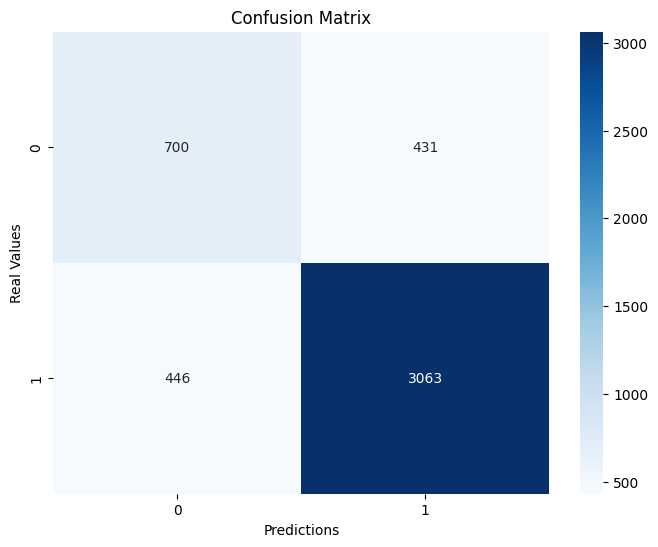

In [22]:
# Calcular a matriz de confusão
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Criar o heatmap da matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predictions")
plt.ylabel("Real Values")
plt.title("Confusion Matrix")
plt.show()

**LIME**

In [23]:
from lime.lime_text import LimeTextExplainer

explainer = LimeTextExplainer(class_names=le.classes_)

def predict_proba(texts):
    X = tfidf.transform(texts)
    X = X.toarray()
    return model.predict(X, verbose=0)

# Solicita ao usuário o número da linha do exemplo
idx = int(input(f"Digite o número da linha (0 a {len(X_test)-1}): "))
sample_text = X_test.iloc[idx]
sample_label = y_test.iloc[idx]

# Predição da classe para o texto selecionado
sample_tfidf = tfidf.transform([sample_text]).toarray()

pred_probs = model.predict(sample_tfidf, verbose=0)
pred_class_idx = pred_probs.argmax(axis=1)[0]
pred_class_name = le.classes_[pred_class_idx]

print(f"Número da linha no X_test: {idx}")
print(f"Original text:\n{sample_text}")
print(f"Classe real: {le.classes_[sample_label]}")
print(f"Classe predita: {pred_class_name}")

explanation = explainer.explain_instance(
    sample_text,
    predict_proba,
    num_features=10
)

print(explanation.as_list())

Número da linha no X_test: 499
Original text:
style tip dressing like princess eleanor royal
Classe real: 1
Classe predita: 1
[(np.str_('eleanor'), 0.015938105544183016), (np.str_('like'), 0.01384868300457625), (np.str_('princess'), 0.013115908581396545), (np.str_('style'), 0.01058973041829802), (np.str_('royal'), 0.004130566540511462), (np.str_('tip'), 0.002106706892801715), (np.str_('dressing'), 0.0002124666743389487)]


In [24]:
# Obtém as palavras mais importantes e seus pesos
lime_features = explanation.as_list()

# Exibe cada palavra com seu impacto na predição
print("Palavras mais importantes e seus pesos:")
for word, weight in lime_features:
    print(f"{word}: {weight:.4f}")

Palavras mais importantes e seus pesos:
eleanor: 0.0159
like: 0.0138
princess: 0.0131
style: 0.0106
royal: 0.0041
tip: 0.0021
dressing: 0.0002


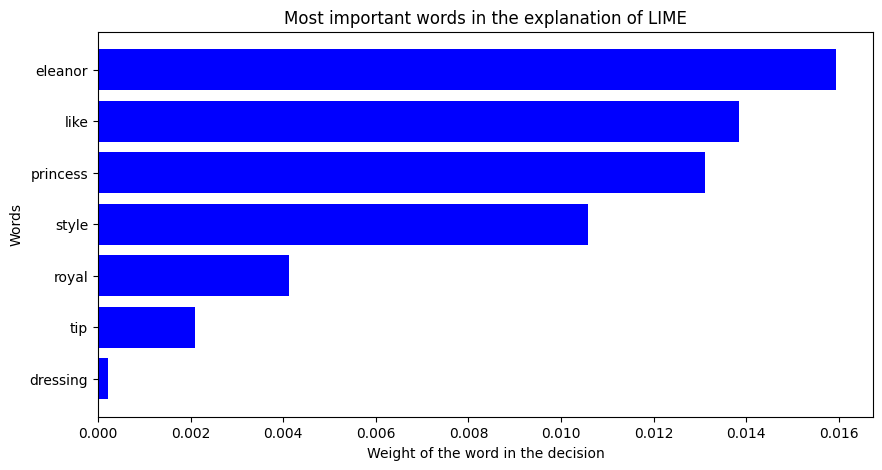

In [25]:
# Separar palavras e pesos
words, weights = zip(*lime_features)

# Criar gráfico de barras
plt.figure(figsize=(10, 5))
plt.barh(words, weights, color="blue")
plt.xlabel("Weight of the word in the decision")
plt.ylabel("Words")
plt.title("Most important words in the explanation of LIME")
plt.gca().invert_yaxis()  # Inverter para mostrar a palavra mais importante no topo
plt.show()

In [26]:
# Obter as palavras mais importantes e seus pesos no geral
words_weights = explanation.as_list()

# Imprimir as palavras e pesos
for word, weight in words_weights:
    print(f"{word}: {weight}")

eleanor: 0.015938105544183016
like: 0.01384868300457625
princess: 0.013115908581396545
style: 0.01058973041829802
royal: 0.004130566540511462
tip: 0.002106706892801715
dressing: 0.0002124666743389487


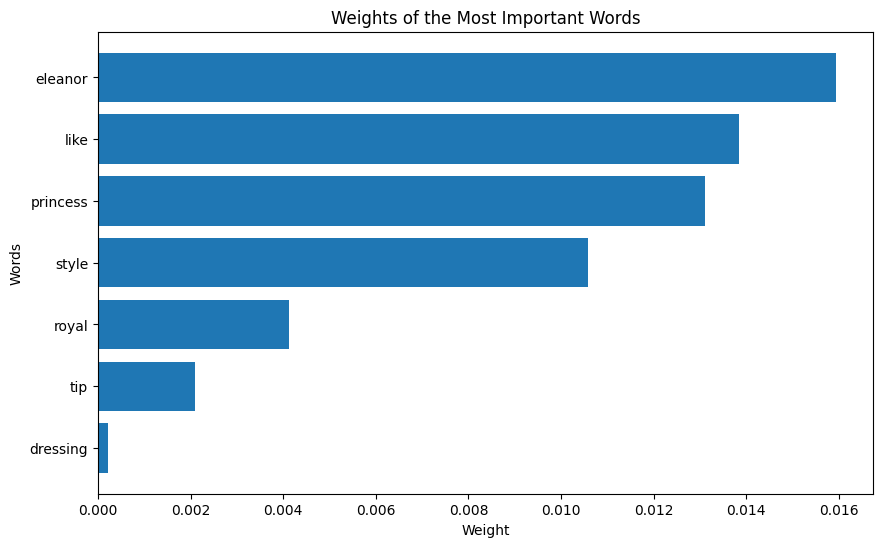

In [27]:
# Obter as palavras mais importantes e seus pesos no geral
words_weights = explanation.as_list()

# Separar palavras e pesos em listas separadas
words = [word for word, weight in words_weights]
weights = [weight for word, weight in words_weights]

# Criar o gráfico de barras horizontais
plt.figure(figsize=(10, 6))  # Ajustar o tamanho da figura, se necessário
plt.barh(words, weights)
plt.xlabel("Weight")
plt.ylabel("Words")
plt.title("Weights of the Most Important Words")
plt.gca().invert_yaxis()  # Inverter o eixo y para que as palavras mais importantes estejam no topo
plt.show()

**Attention Viz**

In [28]:
le.classes_

array([0, 1])

Texto usado na explicação:
style tip dressing like princess eleanor royal

Classe prevista: 1
Probabilidades: [1.8106714e-07 9.9999976e-01 3.0802428e-14]
Camadas Dense encontradas:
0 dense (5000, 256)
1 dense_1 (256, 128)
2 dense_2 (128, 3)

Dimensões:
W1: (5000, 256)
W2: (256, 128)
W3: (128, 3)
Global: (5000, 3)
Importance: (5000,)
TFIDF: (5000,)
Número de palavras: 6
    Feature     TFIDF     Weight  Contribution
0   eleanor  0.553429  31.234184     17.285896
1      like  0.347429  14.251163      4.951261
2  princess  0.379582   7.776145      2.951686
4     style  0.353596   4.805145      1.699078
3     royal  0.321195   2.650322      0.851271
5       tip  0.448030  -5.565868     -2.493677


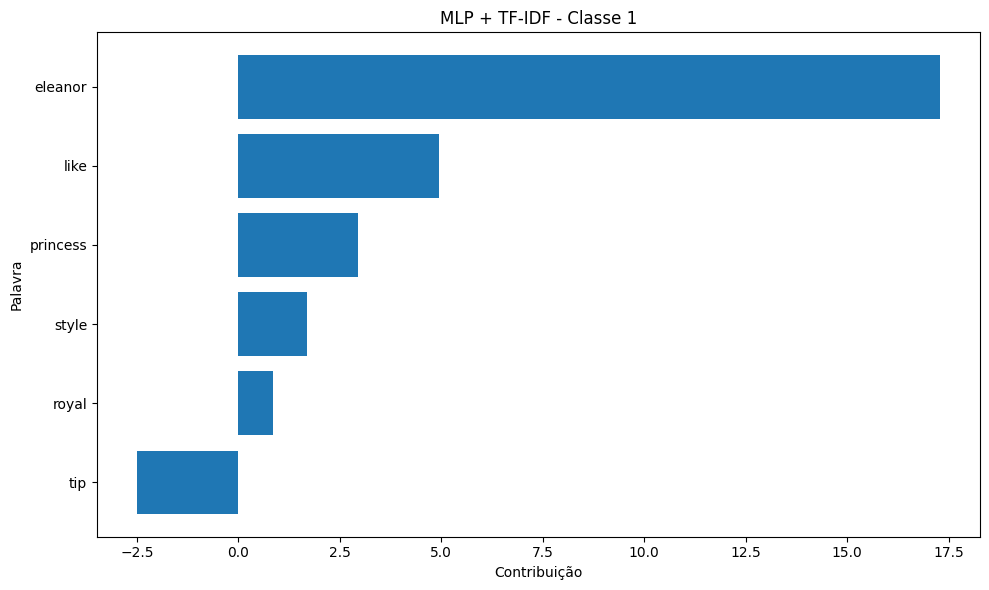

In [29]:
# =====================================================
# MESMO EXEMPLO UTILIZADO NO LIME
# =====================================================

lime_idx = 499

sample_text = X_test.iloc[lime_idx]

print("Texto usado na explicação:")
print(sample_text)

# =====================================================
# ETAPA 1: PREVISÃO DO MODELO
# =====================================================

sample_tfidf = X_test_tfidf[lime_idx:lime_idx+1]

prediction = model.predict(sample_tfidf, verbose=0)

predicted_class_index = np.argmax(prediction[0])

print(f"\nClasse prevista: {predicted_class_index}")
print("Probabilidades:", prediction[0])

# =====================================================
# ETAPA 2: IMPORTÂNCIA GLOBAL DAS FEATURES
# =====================================================

feature_names = tfidf.get_feature_names_out()

# Recuperar apenas as camadas Dense
dense_layers = [layer for layer in model.layers if "Dense" in layer.__class__.__name__]

print("Camadas Dense encontradas:")
for i, layer in enumerate(dense_layers):
    print(i, layer.name, layer.get_weights()[0].shape)

# Matrizes de pesos
W1 = dense_layers[0].get_weights()[0]
W2 = dense_layers[1].get_weights()[0]
W3 = dense_layers[2].get_weights()[0]

print("\nDimensões:")
print("W1:", W1.shape)
print("W2:", W2.shape)
print("W3:", W3.shape)

# Propagação linear dos pesos
global_weights = W1 @ W2 @ W3

print("Global:", global_weights.shape)

# Importância da classe prevista
global_importance = global_weights[:, predicted_class_index]

print("Importance:", global_importance.shape)

# =====================================================
# ETAPA 3: PALAVRAS PRESENTES NO TEXTO
# =====================================================

tfidf_vector = sample_tfidf.toarray().flatten()

print("TFIDF:", tfidf_vector.shape)

indices = np.where(tfidf_vector > 0)[0]

print("Número de palavras:", len(indices))

palavras = feature_names[indices]

pesos = global_importance[indices]

contribuicao = tfidf_vector[indices] * pesos

importancias = pd.DataFrame({
    "Feature": palavras,
    "TFIDF": tfidf_vector[indices],
    "Weight": pesos,
    "Contribution": contribuicao
})

importancias = importancias.sort_values(
    by="Contribution",
    ascending=False
)

print(importancias.head(20))

# =====================================================
# ETAPA 4: VISUALIZAÇÃO
# =====================================================

top = importancias.head(20)

plt.figure(figsize=(10,6))

plt.barh(
    top["Feature"],
    top["Contribution"]
)

plt.xlabel("Contribuição")
plt.ylabel("Palavra")
plt.title(f"MLP + TF-IDF - Classe {predicted_class_index}")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

Shapley 

Classe prevista: 1


  0%|          | 0/1 [00:00<?, ?it/s]c:\Users\LUIRYS SILVA\AppData\Local\Programs\Python\Python311\Lib\site-packages\shap\explainers\_kernel.py:708: UserWarning: Linear regression equation is singular, a least squares solutions is used instead.
To avoid this situation and get a regular matrix do one of the following:
1) turn up the number of samples,
2) turn up the L1 regularization with num_features(N) where N is less than the number of samples,
3) group features together to reduce the number of inputs that need to be explained.
  warnings.warn(
100%|██████████| 1/1 [00:10<00:00, 10.84s/it]


Palavras: ['eleanor' 'like' 'tip' 'style' 'royal' 'princess']
TF-IDF: [0.55342876 0.34742854 0.44803029 0.35359552 0.32119538 0.37958216]
SHAP: [0.06544539 0.00216094 0.         0.         0.         0.        ]


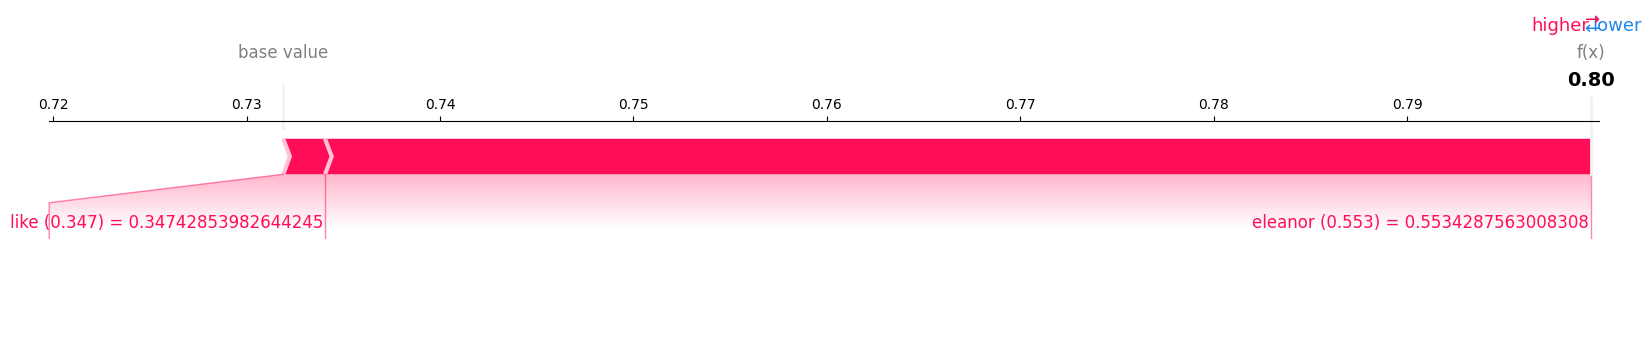

In [30]:
# =====================================================
# Mesma instância utilizada no LIME
# =====================================================

lime_idx = 499

X_instance = X_test_tfidf[lime_idx:lime_idx+1]

# Se estiver usando matriz esparsa
if not isinstance(X_instance, np.ndarray):
    X_instance = X_instance.toarray()

# =====================================================
# Classe prevista
# =====================================================

pred_probs = model.predict(X_instance, verbose=0)

pred_class_idx = np.argmax(pred_probs, axis=1)[0]

print("Classe prevista:", pred_class_idx)

# =====================================================
# Função do SHAP
# =====================================================

def predict_fn(x):
    return model.predict(x, verbose=0)[:, pred_class_idx]

# =====================================================
# Background
# =====================================================

background_size = 100

if isinstance(X_train_tfidf, np.ndarray):
    background = X_train_tfidf[
        np.random.choice(
            X_train_tfidf.shape[0],
            min(background_size, X_train_tfidf.shape[0]),
            replace=False
        )
    ]
else:
    background = X_train_tfidf[
        np.random.choice(
            X_train_tfidf.shape[0],
            min(background_size, X_train_tfidf.shape[0]),
            replace=False
        )
    ].toarray()

# =====================================================
# Kernel SHAP
# =====================================================

explainer = shap.KernelExplainer(
    predict_fn,
    background
)

shap_values = explainer.shap_values(
    X_instance,
    nsamples=100
)

# Compatibilidade entre versões do SHAP
if isinstance(shap_values, list):
    shap_values = shap_values[0]

shap_values = np.array(shap_values).reshape(-1)

expected_value = explainer.expected_value

if isinstance(expected_value, (list, np.ndarray)):
    expected_value = float(np.array(expected_value).reshape(-1)[0])

# =====================================================
# Recuperar palavras presentes no documento
# =====================================================

feature_names = np.array(tfidf.get_feature_names_out())

tfidf_vector = X_instance.reshape(-1)

indices = np.where(tfidf_vector > 0)[0]

words = feature_names[indices]

values = shap_values[indices]

tfidf_values = tfidf_vector[indices]

# =====================================================
# Ordenar por impacto absoluto
# =====================================================

order = np.argsort(np.abs(values))[::-1]

top_k = 15

order = order[:top_k]

words = words[order]

values = values[order]

tfidf_values = tfidf_values[order]

formatted_labels = [
    f"{w} ({t:.3f})"
    for w, t in zip(words, tfidf_values)
]

# =====================================================
# Force Plot
# =====================================================

print("Palavras:", words)
print("TF-IDF:", tfidf_values)
print("SHAP:", values)

shap.force_plot(
    base_value=expected_value,
    shap_values=values,
    features=tfidf_values,
    feature_names=formatted_labels,
    matplotlib=True
)